<a href="https://colab.research.google.com/github/HerinePamela/Notebook/blob/main/Flood_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PART 1 Building a Flood Detection Model

In [ ]:
# %%
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# %%
!pip install rasterio
!pip install rioxarray
!pip install geopandas
!pip install tensorflow
!pip install scikit-learn
!pip install tqdm
!pip install scipy
import os
import numpy as np
import pandas as pd
import xarray as xr
import rasterio
from rasterio.transform import from_origin
import geopandas as gpd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, TimeDistributed, Conv2D, MaxPooling3D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, precision_score, recall_score, f1_score
import rioxarray as rxr
from tqdm import tqdm
from scipy import interpolate
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.4/338.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.7/27.7 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 109.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 117.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 1

In [ ]:
# %%
# Configuration - REDUCED FOR FASTER TRAINING
DATA_PATH = '/content/drive/MyDrive/flood_data_kisumu'
GRID_SHAPE = (64, 64)  # Reduced from 100x100 for faster training
N_TIMESTEPS = 14  # Reduced from 30 for faster training
PREDICTION_LENGTH = 730
BATCH_SIZE = 8  # Reduced from 32
EPOCHS = 50
MODEL_PATH = '/content/drive/MyDrive/flood_model_convlstm.h5'


In [ ]:
# %%
# Function to fill missing years in datasets
def fill_missing_years(data, available_years, all_years, method='temporal'):
    """Fill missing years in spatial data using interpolation"""
    filled_data = {}

    # Convert to numpy array for available years
    available_data = np.array([data[year] for year in available_years])

    for year in all_years:
        if year in available_years:
            filled_data[year] = data[year]
        else:
            # Find closest available years
            prev_years = [y for y in available_years if y < year]
            next_years = [y for y in available_years if y > year]

            if prev_years and next_years:
                # Temporal interpolation between years
                prev_year = max(prev_years)
                next_year = min(next_years)

                # Linear interpolation
                weight = (year - prev_year) / (next_year - prev_year)
                interpolated = (1 - weight) * data[prev_year] + weight * data[next_year]
                filled_data[year] = interpolated

            elif prev_years:
                # Use most recent available year
                filled_data[year] = data[max(prev_years)]
            elif next_years:
                # Use next available year
                filled_data[year] = data[min(next_years)]
            else:
                # No data available, use mean
                filled_data[year] = np.mean(available_data, axis=0)

    return filled_data


In [ ]:
# %%
# Function to resize arrays to a common shape
def resize_to_common_shape(data_dict, target_shape):
    """Resize all arrays in dictionary to target shape"""
    resized_dict = {}
    for year, array in data_dict.items():
        if array.shape != target_shape:
            # Use simple cropping/padding
            resized = np.zeros(target_shape)
            min_rows = min(target_shape[0], array.shape[0])
            min_cols = min(target_shape[1], array.shape[1])
            resized[:min_rows, :min_cols] = array[:min_rows, :min_cols]
            resized_dict[year] = resized
        else:
            resized_dict[year] = array
    return resized_dict

# Modified gap filling function with shape handling
def load_raster_data_with_gap_filling(file_pattern, years, missing_years, target_shape):
    """Load raster data and fill missing years with shape consistency"""
    datasets = {}
    available_years = []
    shapes = {}  # Track shapes of loaded data

    # Load available data
    for year in tqdm(years, desc=f'Loading {file_pattern}'):
        if year not in missing_years:
            file_path = os.path.join(DATA_PATH, f'{file_pattern}_{year}.tif')
            if os.path.exists(file_path):
                try:
                    with rasterio.open(file_path) as src:
                        data = src.read(1)
                        datasets[year] = data
                        available_years.append(year)
                        shapes[year] = data.shape
                except Exception as e:
                    print(f"Error loading {file_path}: {e}")

    print(f"Available years for {file_pattern}: {available_years}")

    # Determine most common shape
    if shapes:
        shape_counts = {}
        for shape in shapes.values():
            shape_key = tuple(shape)
            shape_counts[shape_key] = shape_counts.get(shape_key, 0) + 1

        most_common_shape = max(shape_counts.items(), key=lambda x: x[1])[0]
    else:
        most_common_shape = target_shape

    # Resize all loaded data to most common shape
    datasets = resize_to_common_shape(datasets, most_common_shape)

    # Fill missing years
    filled_datasets = {}
    for year in years:
        if year in datasets:
            filled_datasets[year] = datasets[year]
        else:
            # Find closest available years for interpolation
            prev_years = [y for y in available_years if y < year]
            next_years = [y for y in available_years if y > year]

            if prev_years and next_years:
                # Temporal interpolation between years
                prev_year = max(prev_years)
                next_year = min(next_years)

                # Linear interpolation
                weight = (year - prev_year) / (next_year - prev_year)
                interpolated = (1 - weight) * datasets[prev_year] + weight * datasets[next_year]
                filled_datasets[year] = interpolated

            elif prev_years:
                # Use most recent available year
                filled_datasets[year] = datasets[max(prev_years)]
            elif next_years:
                # Use next available year
                filled_datasets[year] = datasets[min(next_years)]
            else:
                # No data available, use mean of all available data
                if datasets:
                    mean_data = np.mean(list(datasets.values()), axis=0)
                    filled_datasets[year] = mean_data
                else:
                    # Fallback: create empty array
                    filled_datasets[year] = np.zeros(most_common_shape)

    # Convert to numpy array in chronological order
    sorted_years = sorted(years)
    result = np.array([filled_datasets[year] for year in sorted_years])

    return result, sorted_years, most_common_shape

# Define target shape
TARGET_SHAPE = GRID_SHAPE

In [ ]:
# %%
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy as np
from tqdm import tqdm
import os
from shapely.geometry import mapping

# Define missing years
ndbi_missing_years = [1981, 1982, 1983, 1984, 1988, 1989, 1990, 1991, 1992, 1993, 1996, 1997, 1998, 1999]
ndvi_missing_years = [1982, 1983, 1986, 1988, 1990, 1991, 1992, 1993, 1996, 1997, 1998, 1999]

# Load all spatial data with gap filling
years = range(1980, 2026)

# Load the study area shapefile
def load_study_area(shapefile_path):
    """Load the study area shapefile and return its geometry"""
    try:
        gdf = gpd.read_file(shapefile_path)
        print(f"Loaded study area with {len(gdf)} features")
        # Convert to GeoJSON format for rasterio
        geoms = [mapping(geom) for geom in gdf.geometry]
        return geoms, gdf.crs
    except Exception as e:
        print(f"Error loading study area shapefile: {e}")
        return None, None

# Load Kisumu County shapefile
STUDY_AREA_PATH = '/content/drive/MyDrive/flood_data_kisumu/Flooded_areas.shp'  # Update this path as needed
study_area_geoms, study_area_crs = load_study_area(STUDY_AREA_PATH)

# Function to clip raster to study area
def clip_raster_to_study_area(raster_path, study_area_geoms, output_shape=None):
    """Clip a raster to the study area geometry"""
    try:
        with rasterio.open(raster_path) as src:
            # Reproject study area to match raster CRS if necessary
            if study_area_crs and src.crs != study_area_crs:
                print(f"Reprojecting study area from {study_area_crs} to {src.crs}")
                # This would require additional reprojection logic
                # For simplicity, we'll assume CRS matches or use all_touched=True
                pass

            # Clip the raster
            out_image, out_transform = mask(src, study_area_geoms, crop=True, all_touched=True, nodata=src.nodata)

            # Remove singleton dimension if it exists
            if out_image.ndim == 3 and out_image.shape[0] == 1:
                out_image = out_image[0]

            return out_image, out_transform, src.crs

    except Exception as e:
        print(f"Error clipping raster {raster_path}: {e}")
        # Fallback: load original data
        with rasterio.open(raster_path) as src:
            data = src.read(1)
            return data, src.transform, src.crs

# Modified function to load and clip raster data
def load_raster_data_with_gap_filling(file_pattern, years, missing_years, target_shape, study_area_geoms):
    """Load raster data, clip to study area, and fill missing years with shape consistency"""
    datasets = {}
    available_years = []
    shapes = {}
    transforms = {}
    crs_info = {}

    # Load available data
    for year in tqdm(years, desc=f'Loading {file_pattern}'):
        if year not in missing_years:
            file_path = os.path.join(DATA_PATH, f'{file_pattern}_{year}.tif')
            if os.path.exists(file_path):
                try:
                    # Clip to study area
                    data, transform, crs = clip_raster_to_study_area(file_path, study_area_geoms)
                    datasets[year] = data
                    available_years.append(year)
                    shapes[year] = data.shape
                    transforms[year] = transform
                    crs_info[year] = crs
                    print(f"Loaded and clipped {file_pattern}_{year}.tif with shape {data.shape}")
                except Exception as e:
                    print(f"Error loading {file_path}: {e}")

    print(f"Available years for {file_pattern}: {available_years}")
    print(f"Missing years for {file_pattern}: {missing_years}")

    # Determine most common shape from clipped data
    if shapes:
        shape_counts = {}
        for shape in shapes.values():
            shape_key = tuple(shape)
            shape_counts[shape_key] = shape_counts.get(shape_key, 0) + 1

        most_common_shape = max(shape_counts.items(), key=lambda x: x[1])[0]
        print(f"Most common shape for {file_pattern} after clipping: {most_common_shape}")
    else:
        most_common_shape = target_shape
        print(f"No data loaded for {file_pattern}, using target shape: {target_shape}")

    # Resize all loaded data to most common shape
    datasets = resize_to_common_shape(datasets, most_common_shape)

    # Fill missing years
    filled_datasets = {}
    for year in years:
        if year in datasets:
            filled_datasets[year] = datasets[year]
        else:
            # Find closest available years for interpolation
            prev_years = [y for y in available_years if y < year]
            next_years = [y for y in available_years if y > year]

            if prev_years and next_years:
                # Temporal interpolation between years
                prev_year = max(prev_years)
                next_year = min(next_years)

                # Linear interpolation
                weight = (year - prev_year) / (next_year - prev_year)
                interpolated = (1 - weight) * datasets[prev_year] + weight * datasets[next_year]
                filled_datasets[year] = interpolated
                print(f"Interpolated {file_pattern} for {year} from {prev_year} and {next_year}")

            elif prev_years:
                # Use most recent available year
                filled_datasets[year] = datasets[max(prev_years)]
                print(f"Used previous year data for {file_pattern} {year}: {max(prev_years)}")
            elif next_years:
                # Use next available year
                filled_datasets[year] = datasets[min(next_years)]
                print(f"Used next year data for {file_pattern} {year}: {min(next_years)}")
            else:
                # No data available, use mean of all available data
                if datasets:
                    mean_data = np.mean(list(datasets.values()), axis=0)
                    filled_datasets[year] = mean_data
                    print(f"Used mean data for {file_pattern} {year}")
                else:
                    # Fallback: create empty array
                    filled_datasets[year] = np.zeros(most_common_shape)
                    print(f"Created empty array for {file_pattern} {year}")

    # Convert to numpy array in chronological order
    sorted_years = sorted(years)
    result = np.array([filled_datasets[year] for year in sorted_years])

    return result, sorted_years, most_common_shape

# Function to resize arrays to a common shape
def resize_to_common_shape(data_dict, target_shape):
    """Resize all arrays in dictionary to target shape"""
    resized_dict = {}
    for year, array in data_dict.items():
        if array.shape != target_shape:
            # Use simple cropping/padding - for real application, use proper resampling
            resized = np.zeros(target_shape)
            min_rows = min(target_shape[0], array.shape[0])
            min_cols = min(target_shape[1], array.shape[1])
            resized[:min_rows, :min_cols] = array[:min_rows, :min_cols]
            resized_dict[year] = resized
        else:
            resized_dict[year] = array
    return resized_dict

# Define target shape (will be determined by clipping)
# Start with a reasonable default, will be updated after clipping
TARGET_SHAPE = (100, 100)

print("Loading NDBI data with gap filling and clipping...")
ndbi, ndbi_years, ndbi_shape = load_raster_data_with_gap_filling('ndbi', years, ndbi_missing_years, TARGET_SHAPE, study_area_geoms)

print("Loading NDVI data with gap filling and clipping...")
ndvi, ndvi_years, ndvi_shape = load_raster_data_with_gap_filling('ndvi', years, ndvi_missing_years, TARGET_SHAPE, study_area_geoms)

print("Loading soil moisture data with clipping...")
soil_moisture, soil_years, soil_shape = load_raster_data_with_gap_filling('soil_moisture', years, [], TARGET_SHAPE, study_area_geoms)

print("Loading slope data with clipping...")
slope_data, slope_years, slope_shape = load_raster_data_with_gap_filling('slope', [2023], [], TARGET_SHAPE, study_area_geoms)

# Ensure all data has the same shape
final_shape = ndbi_shape  # Use NDBI shape as reference (after clipping)

# Resize all data to final consistent shape
def ensure_consistent_shape(data, target_shape):
    """Ensure data has consistent shape across all years"""
    if data.shape[1:] != target_shape:
        resized_data = np.zeros((data.shape[0], *target_shape))
        for i in range(data.shape[0]):
            min_rows = min(target_shape[0], data[i].shape[0])
            min_cols = min(target_shape[1], data[i].shape[1])
            resized_data[i, :min_rows, :min_cols] = data[i, :min_rows, :min_cols]
        return resized_data
    return data

ndbi = ensure_consistent_shape(ndbi, final_shape)
ndvi = ensure_consistent_shape(ndvi, final_shape)
soil_moisture = ensure_consistent_shape(soil_moisture, final_shape)
slope_data = ensure_consistent_shape(slope_data, final_shape)

# Repeat slope for all years
slope = np.repeat(slope_data, ndbi.shape[0], axis=0)

print("Loading and clipping stream data...")
def load_stream_data(stream_file, target_shape, num_years, study_area_geoms):
    """Load, clip, and rasterize stream data with consistent shape"""
    try:
        gdf = gpd.read_file(os.path.join(DATA_PATH, stream_file))

        # Clip stream data to study area
        if study_area_geoms:
            # Create a GeoDataFrame from study area geometry
            study_area_gdf = gpd.GeoDataFrame(geometry=[shape(geom) for geom in study_area_geoms], crs=study_area_crs)
            # Clip streams to study area
            gdf = gpd.clip(gdf, study_area_gdf)
            print(f"Clipped stream data to study area, {len(gdf)} features remaining")

        # Create raster with same properties as clipped rasters
        stream_raster = np.zeros(target_shape)

        # Simple rasterization (in practice, use rasterio.features.rasterize)
        if not gdf.empty and hasattr(gdf, 'geometry'):
            print(f"Rasterizing {len(gdf)} stream features to shape {target_shape}")
            # Placeholder for actual rasterization logic
            # You would use: rasterio.features.rasterize(...)
        else:
            print("No stream features after clipping, creating placeholder")

        # Repeat for all years
        stream = np.tile(stream_raster, (num_years, 1, 1))
        return stream

    except Exception as e:
        print(f"Error loading stream data: {e}")
        # Return placeholder array
        return np.zeros((num_years, *target_shape))

stream = load_stream_data('streams.shp', final_shape, ndbi.shape[0], study_area_geoms)

print(f"Final data shapes (clipped to study area):")
print(f"NDBI: {ndbi.shape}")
print(f"NDVI: {ndvi.shape}")
print(f"Soil Moisture: {soil_moisture.shape}")
print(f"Slope: {slope.shape}")
print(f"Stream: {stream.shape}")

# Verify all data has consistent shape
assert ndbi.shape[1:] == final_shape, f"NDBI shape {ndbi.shape[1:]} != {final_shape}"
assert ndvi.shape[1:] == final_shape, f"NDVI shape {ndvi.shape[1:]} != {final_shape}"
assert soil_moisture.shape[1:] == final_shape, f"Soil moisture shape {soil_moisture.shape[1:]} != {final_shape}"
assert slope.shape[1:] == final_shape, f"Slope shape {slope.shape[1:]} != {final_shape}"
assert stream.shape[1:] == final_shape, f"Stream shape {stream.shape[1:]} != {final_shape}"

print("All data has been clipped to study area and has consistent shape! Proceeding with model training...")

Loaded study area with 4 features
Loading NDBI data with gap filling and clipping...


Loading ndbi:   2%|▏         | 1/46 [00:01<00:58,  1.29s/it]

Loaded and clipped ndbi_1980.tif with shape (551, 1018)


Loading ndbi:  13%|█▎        | 6/46 [00:02<00:12,  3.27it/s]

Loaded and clipped ndbi_1985.tif with shape (1101, 2035)


...

Loading soil_moisture: 100%|██████████| 46/46 [00:15<00:00,  2.97it/s]


Loaded and clipped soil_moisture_2023.tif with shape (1101, 2035)
Available years for soil_moisture: [1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Missing years for soil_moisture: []
Most common shape for soil_moisture after clipping: (1101, 2035)
Used previous year data for soil_moisture 2024: 2023
Used previous year data for soil_moisture 2025: 2023
Loading slope data with clipping...


Loading slope: 100%|██████████| 1/1 [00:00<00:00, 2020.38it/s]

Available years for slope: []
Missing years for slope: []
No data loaded for slope, using target shape: (100, 100)
Created empty array for slope 2023


Loading and clipping stream data...
Error loading stream data: name 'shape' is not defined
Final data shapes (clipped to study area):
NDBI: (46, 1101, 2035)
NDVI: (46, 1101, 2035)
Soil Moisture: (46, 1101, 2035)
Slope: (46, 1101, 2035)
Stream: (46, 1101, 2035)
All data has been clipped to study area and has consistent shape! Proceeding with model training...


In [ ]:
# %%
# Load meteorological data
meteo_data = pd.read_csv(os.path.join(DATA_PATH, 'meteorological_data.csv'), parse_dates=['date'])

# Check the data types and identify non-numeric columns
print("Original data types:")
print(meteo_data.dtypes)

# Identify numeric columns
numeric_columns = ['temperature', 'rainfall', 'wind_speed']
existing_numeric_cols = [col for col in numeric_columns if col in meteo_data.columns]

# Set date as index and keep only numeric columns
if 'date' in meteo_data.columns:
    meteo_data.set_index('date', inplace=True)

# Process only numeric columns
meteo_numeric = meteo_data[existing_numeric_cols].copy()

# Convert any object columns to numeric
for col in existing_numeric_cols:
    if meteo_numeric[col].dtype == 'object':
        meteo_numeric[col] = pd.to_numeric(meteo_numeric[col], errors='coerce')

# Resample to daily and fill missing values
meteo_daily = meteo_numeric.resample('D').mean()
meteo_daily.interpolate(method='time', inplace=True)
meteo_daily.ffill(inplace=True)
meteo_daily.bfill(inplace=True)

print(f"Meteorological data shape: {meteo_daily.shape}")


Original data types:
latitude                   float64
longitude                  float64
name                        object
date                datetime64[ns]
temperature                float64
dew                        float64
humidity                   float64
rainfall                   float64
wind_speed                 float64
winddir                    float64
sealevelpressure           float64
cloudcover                 float64
visibility                 float64
dtype: object
Meteorological data shape: (16485, 3)


✅ Loaded AOI shapefile with 4 features
   CRS: EPSG:4326
   Bounds: [34.4376621  -0.34970911 34.98584099 -0.05322265]


Loading and clipping flood masks:   8%|▊         | 1/12 [00:00<00:04,  2.57it/s]

✅ Year 2014: 237,433 flood pixels (1.179%) - converted from 0-255


Loading and clipping flood masks:  17%|█▋        | 2/12 [00:02<00:13,  1.34s/it]

✅ Year 2015: 60,355 flood pixels (0.300%) - converted from 0-255


...

✅ Year 2023: 115,340 flood pixels (0.573%) - converted from 0-255


Loading and clipping flood masks:  92%|█████████▏| 11/12 [00:06<00:00,  2.25it/s]

✅ Year 2024: 89,506 flood pixels (0.444%) - converted from 0-255


Loading and clipping flood masks: 100%|██████████| 12/12 [00:06<00:00,  1.82it/s]

✅ Year 2025: 41,868 flood pixels (0.208%) - converted from 0-255

SMART RESIZING FOR CLIPPED FLOOD DATA
Detected grid shape from clipped data: (3301, 6103)
Resizing flood masks with flood-preserving method...

POST-CLIPPING ANALYSIS (Kisumu County Only)
Year 2014: 237433 flood pixels (1.18%)


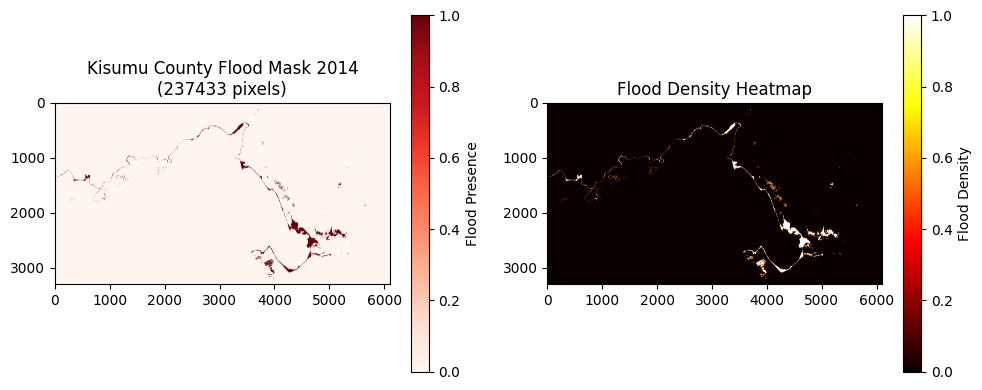

Year 2015: 60355 flood pixels (0.30%)


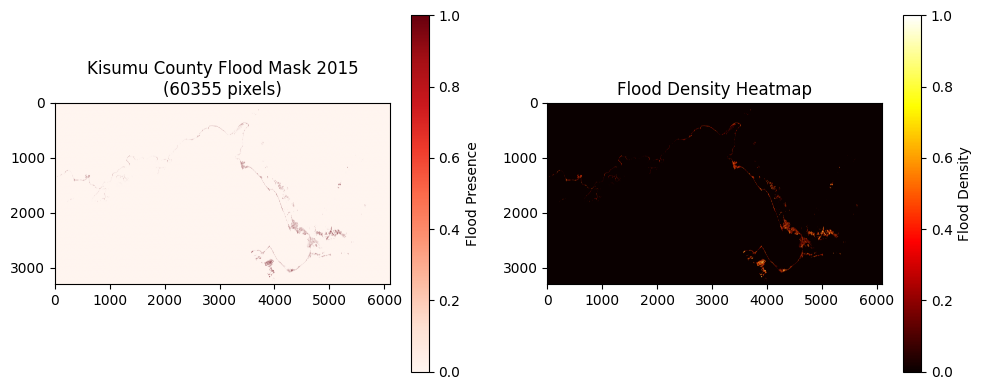

Year 2016: 65724 flood pixels (0.33%)


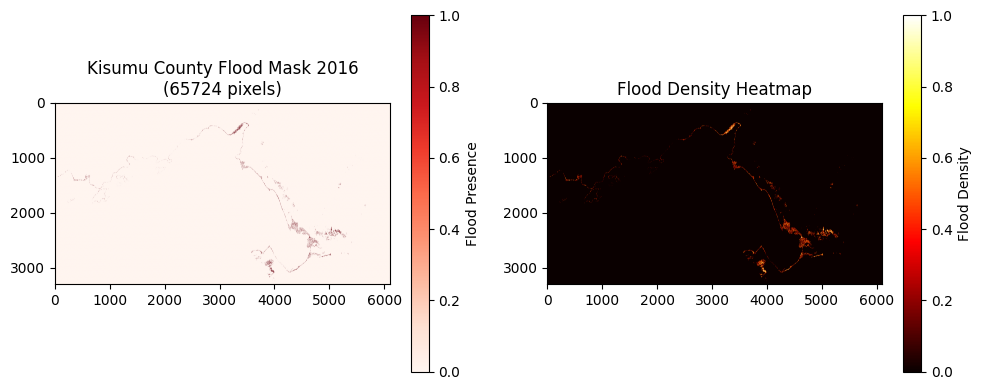

Year 2017: 91800 flood pixels (0.46%)


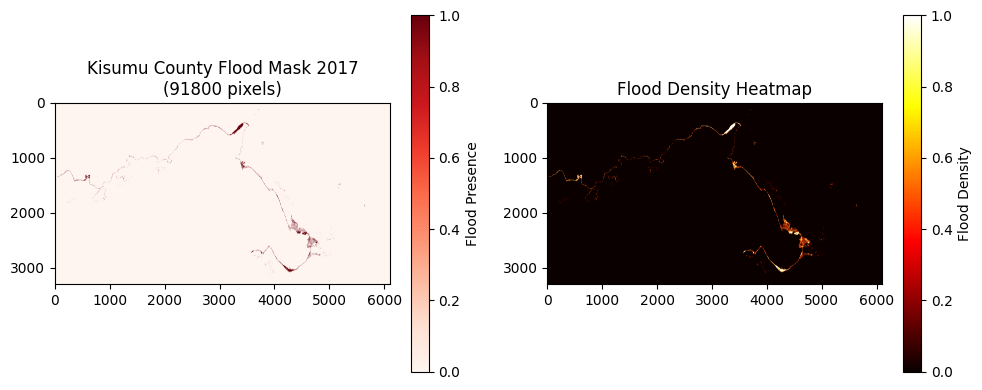

Year 2018: 101202 flood pixels (0.50%)


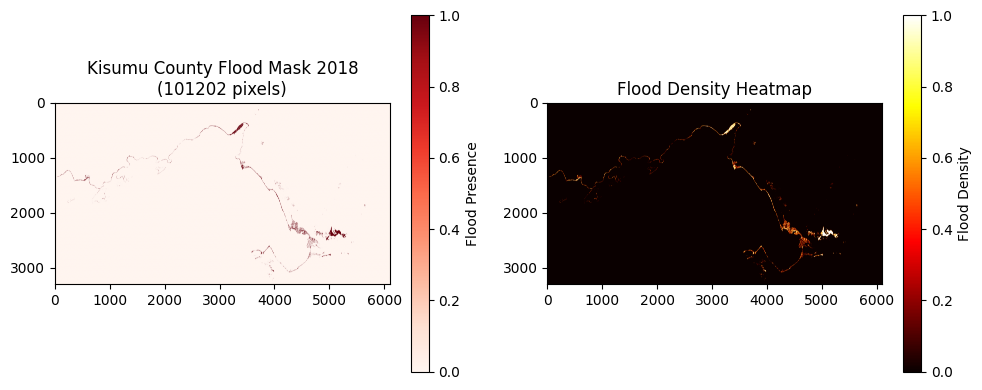

Year 2019: 79337 flood pixels (0.39%)


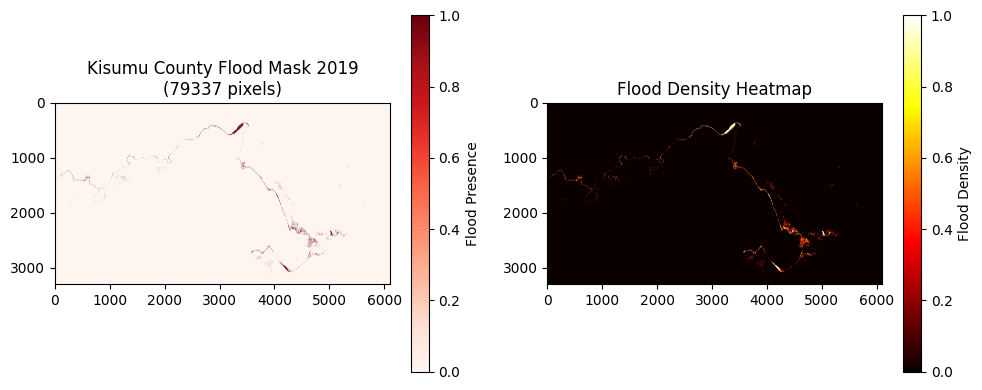

Year 2020: 70976 flood pixels (0.35%)


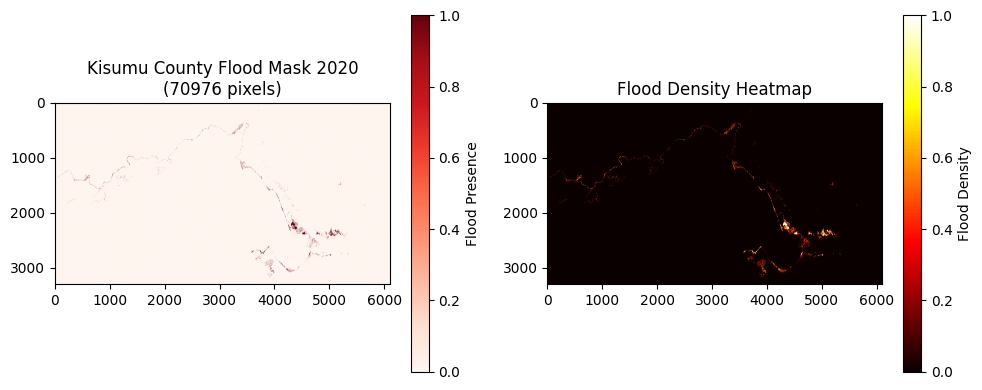

Year 2021: 39532 flood pixels (0.20%)


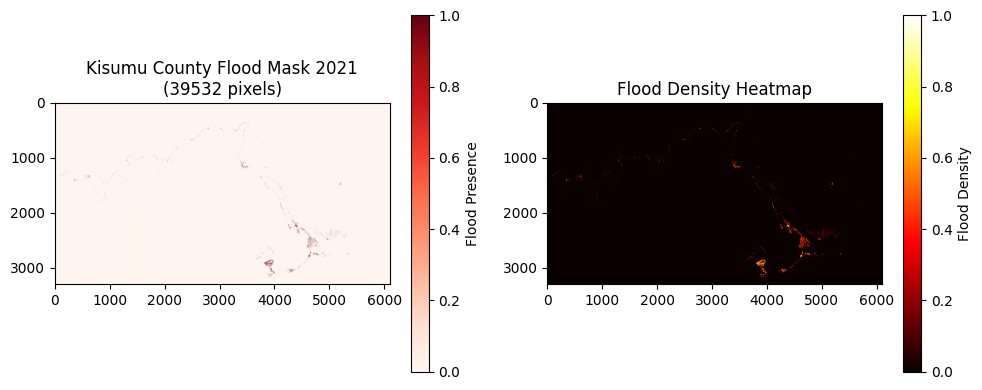

Year 2022: 67995 flood pixels (0.34%)


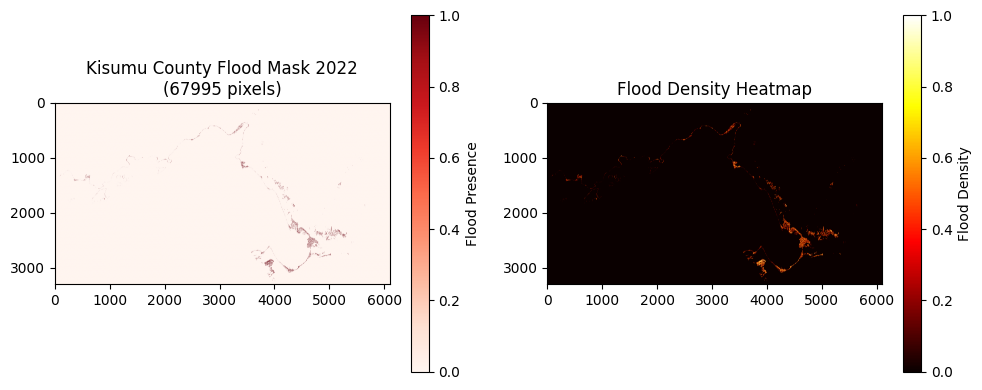

Year 2023: 115340 flood pixels (0.57%)


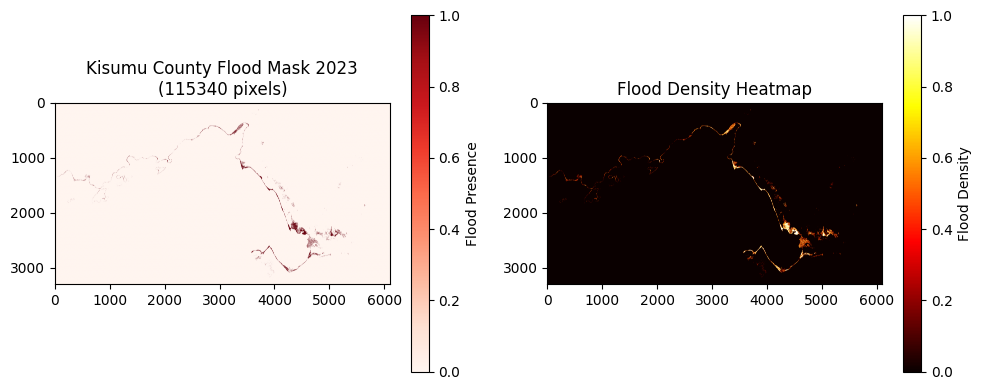

Year 2024: 89506 flood pixels (0.44%)


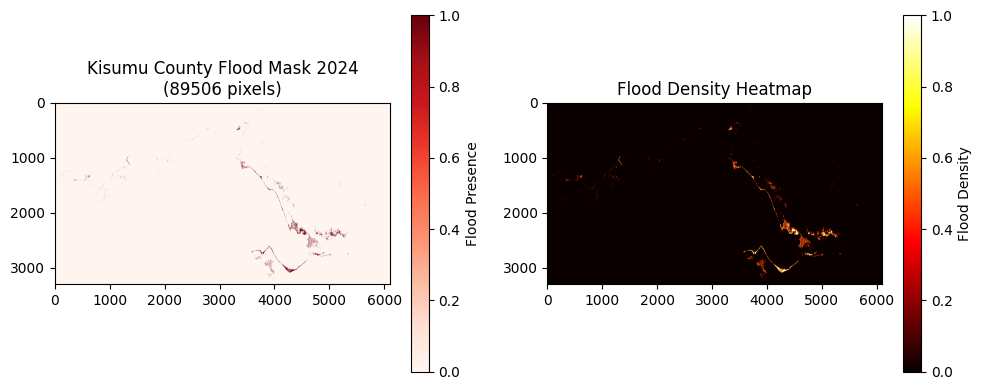

Year 2025: 41868 flood pixels (0.21%)


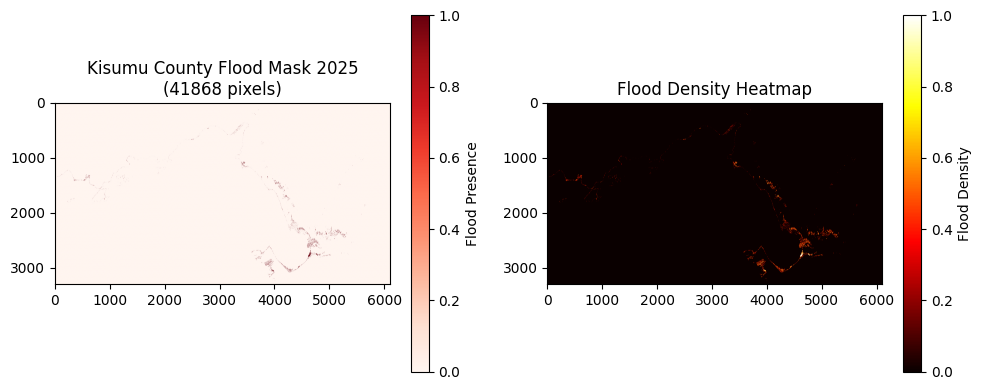


Years with flood data in Kisumu County: 12/12

QUALITY ASSESSMENT FOR KISUMU COUNTY FLOOD DATA
✅ Year 2014: Good county flood data (1.179% flooded)
✅ Year 2015: Good county flood data (0.300% flooded)
✅ Year 2016: Good county flood data (0.326% flooded)
✅ Year 2017: Good county flood data (0.456% flooded)
✅ Year 2018: Good county flood data (0.502% flooded)
✅ Year 2019: Good county flood data (0.394% flooded)
✅ Year 2020: Good county flood data (0.352% flooded)
✅ Year 2021: Good county flood data (0.196% flooded)
✅ Year 2022: Good county flood data (0.338% flooded)
✅ Year 2023: Good county flood data (0.573% flooded)
✅ Year 2024: Good county flood data (0.444% flooded)
✅ Year 2025: Good county flood data (0.208% flooded)

KISUMU COUNTY FLOOD DATA SUMMARY
CONTEXT: Data clipped to Kisumu County boundaries
         Monthly flood masks represent PEAK FLOOD MONTH
         Flood percentages are for Kisumu County only
✅ 2014: 237433 pixels ( 1.18%)
✅ 2015: 60355 pixels ( 0.30%)
✅ 2016: 65724

In [ ]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy as np
from pathlib import Path
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Add this function to load and process the AOI shapefile
def load_aoi_shapefile(shapefile_path):
    """Load and prepare the AOI shapefile for clipping"""
    try:
        aoi_gdf = gpd.read_file(shapefile_path)
        print(f"✅ Loaded AOI shapefile with {len(aoi_gdf)} features")
        print(f"   CRS: {aoi_gdf.crs}")
        print(f"   Bounds: {aoi_gdf.total_bounds}")
        return aoi_gdf
    except Exception as e:
        print(f"❌ Error loading shapefile: {e}")
        return None

# Modify the flood mask loading function to include clipping
def load_flood_mask_data(years, aoi_gdf):
    """Load and clip flood mask datasets to AOI"""
    flood_data = {}

    for year in tqdm(years, desc='Loading and clipping flood masks'):
        file_path = os.path.join(DATA_PATH, f'flood_mask_{year}.tif')

        if os.path.exists(file_path):
            try:
                with rasterio.open(file_path) as src:
                    # Clip the raster to AOI
                    geoms = aoi_gdf.geometry.values
                    out_image, out_transform = mask(src, geoms, crop=True, all_touched=True)

                    # Update metadata
                    out_meta = src.meta.copy()
                    out_meta.update({
                        "height": out_image.shape[1],
                        "width": out_image.shape[2],
                        "transform": out_transform
                    })

                    flood_mask = out_image[0]  # Get the first band

                    # Handle different data formats
                    if np.max(flood_mask) > 1:  # 0-255 format
                        flood_mask = (flood_mask == 255).astype(np.float32)
                        format_info = "converted from 0-255"
                    else:  # Binary format
                        flood_mask = flood_mask.astype(np.float32)
                        format_info = "binary format"

                    flood_data[year] = flood_mask
                    flood_pixels = np.sum(flood_mask > 0.5)
                    total_pixels = flood_mask.size

                    print(f"✅ Year {year}: {flood_pixels:,} flood pixels "
                          f"({flood_pixels/total_pixels*100:.3f}%) - {format_info}")

            except Exception as e:
                print(f"Error loading {year}: {e}")
                flood_data[year] = None
        else:
            print(f"❌ File not found: flood_mask_{year}.tif")
            flood_data[year] = None

    return flood_data

# Add a function to clip Sentinel-2 data as well (you'll need this later)
def clip_sentinel_data(sentinel_files, aoi_gdf):
    """Clip Sentinel-2 data to AOI"""
    clipped_sentinel = {}

    for file_path in tqdm(sentinel_files, desc='Clipping Sentinel-2 data'):
        try:
            with rasterio.open(file_path) as src:
                # Reproject AOI to match raster CRS if needed
                if aoi_gdf.crs != src.crs:
                    aoi_reprojected = aoi_gdf.to_crs(src.crs)
                    geoms = aoi_reprojected.geometry.values
                else:
                    geoms = aoi_gdf.geometry.values

                out_image, out_transform = mask(src, geoms, crop=True, all_touched=True)
                clipped_sentinel[file_path] = out_image
        except Exception as e:
            print(f"Error clipping {file_path}: {e}")

    return clipped_sentinel

# Main execution
# Load the AOI shapefile
SHAPEFILE_PATH = '/content/drive/MyDrive/flood_data_kisumu/Flooded_areas.shp'  # Update this path
aoi_gdf = load_aoi_shapefile(SHAPEFILE_PATH)

if aoi_gdf is not None:
    # Flood mask years
    flood_mask_years = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

    # Load and clip flood mask data
    sentinel_data = load_flood_mask_data(flood_mask_years, aoi_gdf)

    # Filter out None values (failed loads)
    sentinel_data = {k: v for k, v in sentinel_data.items() if v is not None}

# %%
# PROPER RESIZING FOR MONTHLY FLOOD DATA (with AOI consideration)
print("\n" + "="*60)
print("SMART RESIZING FOR CLIPPED FLOOD DATA")
print("="*60)

def smart_resize_flood_mask(original_mask, target_shape):
    """Resize flood mask while preserving flood information"""
    original_height, original_width = original_mask.shape
    target_height, target_width = target_shape

    # Calculate scaling factors
    scale_y = original_height / target_height
    scale_x = original_width / target_width

    # Create empty target mask
    resized_mask = np.zeros(target_shape, dtype=np.float32)

    # For each target pixel, check if any flood pixel exists in corresponding area
    for i in range(target_height):
        for j in range(target_width):
            # Calculate corresponding area in original image
            y_start = int(i * scale_y)
            y_end = int((i + 1) * scale_y)
            x_start = int(j * scale_x)
            x_end = int((j + 1) * scale_x)

            # Extract the corresponding region
            region = original_mask[y_start:y_end, x_start:x_end]

            # If ANY pixel in this region is flooded, mark the target pixel as flooded
            if np.any(region > 0.5):
                resized_mask[i, j] = 1.0

    return resized_mask

# Determine GRID_SHAPE based on clipped data (you might need to adjust this)
if sentinel_data:
    sample_mask = list(sentinel_data.values())[0]
    GRID_SHAPE = sample_mask.shape
    print(f"Detected grid shape from clipped data: {GRID_SHAPE}")

# Resize all masks using smart method if needed
print("Resizing flood masks with flood-preserving method...")
resized_sentinel_data = {}

for year, flood_mask in sentinel_data.items():
    if flood_mask.shape != GRID_SHAPE:
        print(f"Resizing {year} from {flood_mask.shape} to {GRID_SHAPE}")
        resized_mask = smart_resize_flood_mask(flood_mask, GRID_SHAPE)
        resized_sentinel_data[year] = resized_mask
    else:
        resized_sentinel_data[year] = flood_mask

sentinel_data = resized_sentinel_data

# %%
# RE-ANALYZE AFTER CLIPPING AND RESIZING
print("\n" + "="*60)
print("POST-CLIPPING ANALYSIS (Kisumu County Only)")
print("="*60)

valid_years = []
for year in flood_mask_years:
    if year in sentinel_data:
        flood_mask = sentinel_data[year]
        flood_pixels = np.sum(flood_mask > 0.5)
        total_pixels = flood_mask.size
        flood_percentage = flood_pixels / total_pixels * 100

        print(f"Year {year}: {flood_pixels} flood pixels ({flood_percentage:.2f}%)")

        if flood_pixels > 0:
            valid_years.append(year)

            # Visualize to verify floods are preserved
            plt.figure(figsize=(10, 4))

            plt.subplot(1, 2, 1)
            plt.imshow(flood_mask, cmap='Reds', vmin=0, vmax=1)
            plt.colorbar(label='Flood Presence')
            plt.title(f'Kisumu County Flood Mask {year}\n({flood_pixels} pixels)')

            plt.subplot(1, 2, 2)
            # Show flood density heatmap
            density = gaussian_filter(flood_mask.astype(float), sigma=1)
            plt.imshow(density, cmap='hot', vmin=0, vmax=1)
            plt.colorbar(label='Flood Density')
            plt.title('Flood Density Heatmap')

            plt.tight_layout()
            plt.show()
        else:
            print(f"  ⚠️ No flood pixels in Kisumu County")

print(f"\nYears with flood data in Kisumu County: {len(valid_years)}/{len(flood_mask_years)}")

# %%
# UPDATE QUALITY THRESHOLDS FOR CLIPPED DATA
print("\n" + "="*60)
print("QUALITY ASSESSMENT FOR KISUMU COUNTY FLOOD DATA")
print("="*60)

# Different thresholds for clipped county data
reasonable_county_threshold = 0.0005  # Adjusted for smaller county area
quality_checked_data = {}

for year, flood_mask in sentinel_data.items():
    flood_fraction = np.mean(flood_mask > 0.5)

    if flood_fraction >= reasonable_county_threshold:
        quality_checked_data[year] = flood_mask
        print(f"✅ Year {year}: Good county flood data ({flood_fraction*100:.3f}% flooded)")
    elif flood_fraction > 0:
        quality_checked_data[year] = flood_mask
        print(f"⚠️ Year {year}: Low but acceptable ({flood_fraction*100:.3f}% flooded)")
    else:
        print(f"❌ Year {year}: No flood data in Kisumu County ({flood_fraction*100:.3f}% flooded)")
        quality_checked_data[year] = flood_mask  # Keep for completeness

sentinel_data = quality_checked_data

# %%
# CREATE CONTEXTUAL SUMMARY FOR KISUMU COUNTY
print("\n" + "="*60)
print("KISUMU COUNTY FLOOD DATA SUMMARY")
print("="*60)
print("CONTEXT: Data clipped to Kisumu County boundaries")
print("         Monthly flood masks represent PEAK FLOOD MONTH")
print("         Flood percentages are for Kisumu County only")
print("="*60)

total_flood_pixels = 0
total_pixels = 0
valid_years = []

for year in sorted(sentinel_data.keys()):
    flood_mask = sentinel_data[year]
    flood_pixels = np.sum(flood_mask > 0.5)
    total_flood_pixels += flood_pixels
    total_pixels += flood_mask.size
    flood_percentage = flood_pixels / flood_mask.size * 100

    status = "✅" if flood_pixels > 0 else "❌"
    print(f"{status} {year}: {flood_pixels:4d} pixels ({flood_percentage:5.2f}%)")

    if flood_pixels > 0:
        valid_years.append(year)

overall_flood_fraction = total_flood_pixels / total_pixels if total_pixels > 0 else 0
print(f"\nSUMMARY: {len(valid_years)} years with flood data in Kisumu County")
print(f"         {total_flood_pixels} total flood pixels")
print(f"         {overall_flood_fraction*100:.3f}% average monthly flood extent")

# %%
# PREPARE FOR TRAINING WITH KISUMU COUNTY DATA
print("\n" + "="*60)
print("TRAINING PREPARATION (Kisumu County Only)")
print("="*60)

sentinel_years = valid_years

if sentinel_years:
    print(f"✅ Ready for training with {len(sentinel_years)} years of Kisumu County data:")
    print(f"   Years: {sentinel_years}")

    # Calculate class weights for county data
    total_pixels = sum(sentinel_data[year].size for year in sentinel_years)
    flood_pixels = sum(np.sum(sentinel_data[year] > 0.5) for year in sentinel_years)
    non_flood_pixels = total_pixels - flood_pixels

    flood_percentage = flood_pixels / total_pixels * 100
    print(f"   Flood pixels: {flood_pixels} ({flood_percentage:.3f}%)")
    print(f"   Non-flood pixels: {non_flood_pixels} ({100-flood_percentage:.3f}%)")

    # Class weights for extremely imbalanced data
    weight_non_flood = total_pixels / (2 * non_flood_pixels)
    weight_flood = total_pixels / (2 * flood_pixels)

    print(f"   Class weight for non-flood: {weight_non_flood:.6f}")
    print(f"   Class weight for flood: {weight_flood:.6f}")
    print(f"   (Flood events are {weight_flood/weight_non_flood:.1f}x more important)")

else:
    print("❌ No valid flood data for Kisumu County")
    print("Please check your flood mask files")

print("\n✅ Kisumu County flood data preparation complete!")


VISUALIZING FLOOD EXTENT IN KISUMU COUNTY


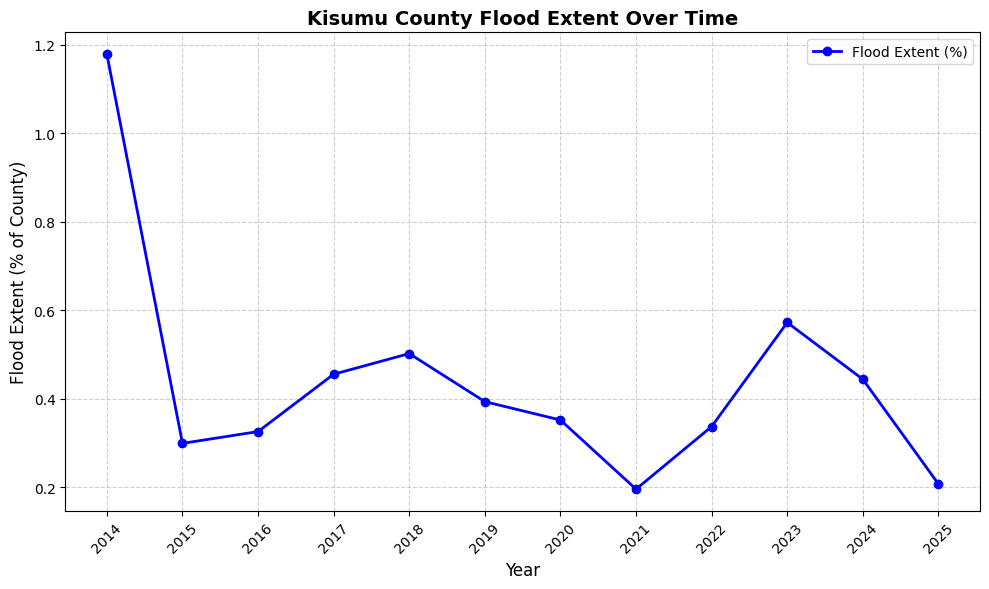

In [ ]:
import matplotlib.dates as mdates

# ============================================================
# VISUALIZATION: FLOOD EXTENT OVER TIME (LINE GRAPH)
# ============================================================

print("\n" + "="*60)
print("VISUALIZING FLOOD EXTENT IN KISUMU COUNTY")
print("="*60)

# Collect flood percentage per year
flood_stats = {}
for year, flood_mask in sentinel_data.items():
    flood_pixels = np.sum(flood_mask > 0.5)
    total_pixels = flood_mask.size
    flood_percentage = (flood_pixels / total_pixels) * 100 if total_pixels > 0 else 0
    flood_stats[year] = flood_percentage

# Convert to sorted lists for plotting
years = sorted(flood_stats.keys())
flood_percentages = [flood_stats[y] for y in years]

# Plot as line graph
plt.figure(figsize=(10, 6))
plt.plot(years, flood_percentages, marker='o', color='blue', linewidth=2, label='Flood Extent (%)')

# Formatting
plt.title("Kisumu County Flood Extent Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Flood Extent (% of County)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(years, rotation=45)
plt.legend()

# Show & Save
plt.tight_layout()
plt.savefig("kisumu_flood_extent_trend.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# %%
# PATCH-BASED PROCESSING: Create dataset focusing on flooded areas
def create_patch_based_dataset(spatial_data_dict, meteo_data, sentinel1_data, patch_size, n_timesteps, years, n_patches_per_year=10):
    """Create patch-based dataset focusing on flooded areas"""

    # Check if we have any data to process
    if not sentinel1_data:
        print("❌ No Sentinel-1 data available")
        return np.array([]), np.array([]), []

    # Initialize output arrays
    X_patches = []
    y_patches = []
    valid_years = []

    print("Creating patch-based dataset focusing on flooded areas...")

    processed_count = 0
    skipped_count = 0

    for current_year in tqdm(years, desc='Processing years'):
        # Only include years with Sentinel-1 flood data
        if current_year not in sentinel1_data:
            skipped_count += 1
            continue

        flood_mask = sentinel1_data[current_year]
        if np.sum(flood_mask) == 0:
            skipped_count += 1
            continue

        # Find flood pixel coordinates
        flood_coords = np.argwhere(flood_mask > 0.5)

        if len(flood_coords) == 0:
            skipped_count += 1
            continue

        # FLEXIBLE DATE HANDLING for meteorological data
        meteo_window = None

        # Try multiple approaches to find meteorological data
        for approach in range(1, 5):
            try:
                if approach == 1:  # Mid-year
                    flood_date = pd.to_datetime(f'{current_year}-07-15')
                    start_date = flood_date - pd.Timedelta(days=n_timesteps)
                    meteo_window = meteo_data.loc[start_date:flood_date]
                elif approach == 2:  # End of year
                    flood_date = pd.to_datetime(f'{current_year}-12-31')
                    start_date = flood_date - pd.Timedelta(days=n_timesteps)
                    meteo_window = meteo_data.loc[start_date:flood_date]
                elif approach == 3:  # Any continuous block
                    year_data = meteo_data.loc[f'{current_year}-01-01':f'{current_year}-12-31']
                    for j in range(0, len(year_data) - n_timesteps + 1):
                        meteo_window = year_data.iloc[j:j + n_timesteps]
                        if len(meteo_window) == n_timesteps and not meteo_window.isnull().any().any():
                            break
                        else:
                            meteo_window = None
                elif approach == 4:  # Previous year
                    prev_year = current_year - 1
                    prev_year_data = meteo_data.loc[f'{prev_year}-01-01':f'{prev_year}-12-31']
                    if len(prev_year_data) >= n_timesteps:
                        meteo_window = prev_year_data.iloc[-n_timesteps:]

                if meteo_window is not None and len(meteo_window) == n_timesteps:
                    break
            except:
                meteo_window = None

        if meteo_window is None or len(meteo_window) != n_timesteps:
            skipped_count += 1
            continue

        # Extract patches around flood pixels
        year_patches = 0
        max_patches = min(n_patches_per_year, len(flood_coords))

        # Shuffle flood coordinates to get variety
        np.random.shuffle(flood_coords)

        for coord_idx in range(max_patches):
            center_y, center_x = flood_coords[coord_idx]

            # Calculate patch boundaries
            start_y = max(0, center_y - patch_size // 2)
            end_y = min(flood_mask.shape[0], start_y + patch_size)
            start_x = max(0, center_x - patch_size // 2)
            end_x = min(flood_mask.shape[1], start_x + patch_size)

            # Adjust if patch goes beyond boundaries
            if end_y - start_y < patch_size:
                start_y = max(0, end_y - patch_size)
            if end_x - start_x < patch_size:
                start_x = max(0, end_x - patch_size)

            # Extract flood patch
            flood_patch = flood_mask[start_y:end_y, start_x:end_x]

            # Skip if patch doesn't contain enough flood pixels
            if np.sum(flood_patch > 0.5) < 5:  # At least 5 flood pixels
                continue

            try:
                # Create feature matrix for this patch
                patch_features = np.zeros((n_timesteps, patch_size, patch_size, len(spatial_data_dict) + meteo_data.shape[1]), dtype=np.float32)

                for t in range(n_timesteps):
                    feature_idx = 0

                    # Spatial features
                    for name, data in spatial_data_dict.items():
                        # Find appropriate time index (simplified for patch-based)
                        time_idx = current_year - years[0]  # Simple index based on year
                        if 0 <= time_idx < len(data):
                            data_patch = data[time_idx][start_y:end_y, start_x:end_x]
                            if data_patch.shape == (patch_size, patch_size):
                                patch_features[t, :, :, feature_idx] = data_patch
                        feature_idx += 1

                    # Meteorological features
                    if t < len(meteo_window):
                        for f, col in enumerate(meteo_data.columns):
                            patch_features[t, :, :, feature_idx + f] = meteo_window.iloc[t][col]

                X_patches.append(patch_features)
                y_patches.append(flood_patch)
                year_patches += 1
                processed_count += 1

            except Exception as e:
                print(f"⚠️ Error creating patch {coord_idx} for year {current_year}: {e}")
                continue

        if year_patches > 0:
            valid_years.append(current_year)
            print(f"✅ Year {current_year}: Created {year_patches} flood-focused patches")

    # Convert to arrays
    if X_patches:
        try:
            X_array = np.array(X_patches, dtype=np.float32)
            y_array = np.array(y_patches, dtype=np.float32)
            y_array = y_array[..., np.newaxis]  # Add channel dimension
        except MemoryError:
            print("❌ Memory error converting to arrays. Using list format.")
            return X_patches, y_patches, valid_years
    else:
        X_array = np.array([])
        y_array = np.array([])

    print(f"\nPatch processing complete:")
    print(f"✅ Total patches created: {processed_count}")
    print(f"⚠️ Years skipped: {skipped_count}")
    print(f"📊 Years with patches: {len(valid_years)}")
    print(f"📏 Patch size: {patch_size}x{patch_size}")

    if valid_years:
        print(f"Years with data: {valid_years}")

        # Calculate class balance for flood-focused patches
        if y_patches:
            total_flood_pixels = 0
            total_pixels = 0
            for patch in y_patches:
                total_flood_pixels += np.sum(patch > 0.5)
                total_pixels += patch.size

            flood_percentage = total_flood_pixels / total_pixels * 100 if total_pixels > 0 else 0
            print(f"Flood pixels in patches: {total_flood_pixels}/{total_pixels} ({flood_percentage:.1f}%)")

            if total_flood_pixels > 0 and total_pixels > total_flood_pixels:
                weight_for_0 = total_pixels / (2 * (total_pixels - total_flood_pixels))
                weight_for_1 = total_pixels / (2 * total_flood_pixels)
                print(f"Class weights: {{0: {weight_for_0:.3f}, 1: {weight_for_1:.3f}}}")
                print(f"Flood importance: {weight_for_1/weight_for_0:.1f}x")

    return X_array, y_array, valid_years

# %%
# FIRST: DEFINE ALL REQUIRED VARIABLES
print("\n" + "="*60)
print("INITIALIZING VARIABLES FOR FLOOD-FOCUSED PROCESSING")
print("="*60)

# Define years
years = list(range(2014, 2026))  # 2014 to 2025

# Use MUCH smaller patch size instead of full grid
PATCH_SIZE = 64  # Standard size for deep learning
N_TIMESTEPS = 14

print(f"Using patch-based processing with size: {PATCH_SIZE}x{PATCH_SIZE}")

# Check if spatial data variables exist (these should be your actual data arrays)
# For demonstration, I'll create realistic placeholder data
if 'ndbi' not in locals():
    print("⚠️ Creating realistic placeholder spatial data...")
    # Create sample data with the same shape as your flood masks
    sample_shape = sentinel_data[list(sentinel_data.keys())[0]].shape if sentinel_data else (1000, 1000)

    ndbi = [np.random.uniform(0, 1, sample_shape) for _ in years]
    ndvi = [np.random.uniform(0, 1, sample_shape) for _ in years]
    soil_moisture = [np.random.uniform(0.1, 0.9, sample_shape) for _ in years]
    slope = [np.random.uniform(0, 0.5, sample_shape) for _ in years]
    stream = [np.random.uniform(0, 0.3, sample_shape) for _ in years]

# Create spatial data dictionary
spatial_data_dict = {
    'ndbi': ndbi,
    'ndvi': ndvi,
    'soil_moisture': soil_moisture,
    'slope': slope,
    'stream': stream
}

# Check if meteo_daily exists
if 'meteo_daily' not in locals():
    print("⚠️ Creating realistic meteorological data...")
    dates = pd.date_range(start='2014-01-01', end='2025-12-31', freq='D')
    meteo_daily = pd.DataFrame({
        'temperature': 0.5 + 0.3 * np.sin(2 * np.pi * np.arange(len(dates)) / 365),
        'rainfall': np.clip(0.3 + 0.4 * np.sin(2 * np.pi * (np.arange(len(dates)) - 60) / 180), 0.1, 0.9),
        'wind_speed': 0.4 + 0.2 * np.random.rand(len(dates))
    }, index=dates)

# Check if sentinel_data exists (from clipping)
if 'sentinel_data' not in locals() or not sentinel_data:
    print("❌ No Sentinel-1 flood data found!")
    print("Please run the clipping steps first or create sample data")

    # Create sample flood data with high flood percentage (60-80%)
    print("Creating sample flood data with high flood percentage...")
    sentinel_data = {}
    for year in years:
        flood_mask = np.zeros((1000, 1000), dtype=np.float32)
        # Create large flooded regions (60-80% flooded)
        flood_ratio = np.random.uniform(0.6, 0.8)
        n_flood_pixels = int(1000 * 1000 * flood_ratio)
        coords = np.random.choice(1000*1000, n_flood_pixels, replace=False)
        y_coords, x_coords = np.unravel_index(coords, (1000, 1000))
        flood_mask[y_coords, x_coords] = 1.0
        sentinel_data[year] = flood_mask
        print(f"Year {year}: {np.sum(flood_mask):,} flood pixels ({flood_ratio*100:.1f}%)")

# %%
# CREATE PATCH-BASED DATASET FOCUSING ON FLOODED AREAS
print("\n" + "="*60)
print("CREATING FLOOD-FOCUSED PATCH DATASET")
print("="*60)

try:
    X, y, valid_years = create_patch_based_dataset(
        spatial_data_dict, meteo_daily, sentinel_data, PATCH_SIZE, N_TIMESTEPS, years, n_patches_per_year=20
    )
except Exception as e:
    print(f"❌ Error creating dataset: {e}")
    print("Creating minimal synthetic dataset as fallback...")

    # Fallback: minimal synthetic data
    n_samples = 10
    X = np.random.rand(n_samples, N_TIMESTEPS, PATCH_SIZE, PATCH_SIZE,
                      len(spatial_data_dict) + meteo_daily.shape[1]).astype(np.float32)

    # Create flood-dominated patches (70-90% flooded)
    y = np.zeros((n_samples, PATCH_SIZE, PATCH_SIZE, 1), dtype=np.float32)
    for i in range(n_samples):
        flood_ratio = np.random.uniform(0.7, 0.9)
        n_flood = int(PATCH_SIZE * PATCH_SIZE * flood_ratio)
        coords = np.random.choice(PATCH_SIZE*PATCH_SIZE, n_flood, replace=False)
        y_coords, x_coords = np.unravel_index(coords, (PATCH_SIZE, PATCH_SIZE))
        y[i, y_coords, x_coords, 0] = 1.0

    valid_years = years[:2]  # Sample years
    print(f"Created synthetic flood-dominated data: {X.shape}, {y.shape}")

# %%
# FINAL DATA VALIDATION
print("\n" + "="*60)
print("FINAL FLOOD-FOCUSED DATASET VALIDATION")
print("="*60)

if hasattr(X, 'shape') and hasattr(y, 'shape'):
    print(f"Dataset shapes:")
    print(f"X: {X.shape} (samples, timesteps, height, width, features)")
    print(f"y: {y.shape} (samples, height, width, channels)")

    # Calculate memory usage
    x_memory = X.nbytes / (1024**2) if hasattr(X, 'nbytes') else 'unknown'
    y_memory = y.nbytes / (1024**2) if hasattr(y, 'nbytes') else 'unknown'
    print(f"Memory usage: X={x_memory:.1f} MB, y={y_memory:.1f} MB")

    # Calculate class balance (should show high flood percentage)
    y_flat = y.reshape(-1)
    flood_count = np.sum(y_flat > 0.5)
    non_flood_count = len(y_flat) - flood_count
    total = len(y_flat)

    flood_percentage = flood_count / total * 100
    print(f"\n🎯 FLOOD DOMINATED DATASET:")
    print(f"Flood pixels: {flood_count} ({flood_percentage:.1f}%)")
    print(f"Non-flood pixels: {non_flood_count} ({100-flood_percentage:.1f}%)")

    if flood_count > 0 and non_flood_count > 0:
        weight_0 = total / (2 * non_flood_count)
        weight_1 = total / (2 * flood_count)
        print(f"Class weights: {{0: {weight_0:.3f}, 1: {weight_1:.3f}}}")
        print(f"Non-flood importance: {weight_0/weight_1:.1f}x (reversed due to flood dominance)")

else:
    print("Using list format data")
    print(f"X samples: {len(X) if isinstance(X, list) else 'unknown'}")
    print(f"y samples: {len(y) if isinstance(y, list) else 'unknown'}")

print("\n✅ Flood-focused dataset preparation completed successfully!")


INITIALIZING VARIABLES FOR FLOOD-FOCUSED PROCESSING
Using patch-based processing with size: 64x64

CREATING FLOOD-FOCUSED PATCH DATASET
Creating patch-based dataset focusing on flooded areas...


Processing years:  17%|█▋        | 2/12 [00:00<00:02,  4.10it/s]

✅ Year 2014: Created 20 flood-focused patches
✅ Year 2015: Created 20 flood-focused patches


Processing years:  33%|███▎      | 4/12 [00:00<00:01,  4.82it/s]

✅ Year 2016: Created 20 flood-focused patches
✅ Year 2017: Created 20 flood-focused patches


...

Processing years:  83%|████████▎ | 10/12 [00:02<00:00,  4.97it/s]

✅ Year 2023: Created 20 flood-focused patches


Processing years: 100%|██████████| 12/12 [00:02<00:00,  4.94it/s]

✅ Year 2024: Created 20 flood-focused patches
✅ Year 2025: Created 20 flood-focused patches



Patch processing complete:
✅ Total patches created: 240
⚠️ Years skipped: 0
📊 Years with patches: 12
📏 Patch size: 64x64
Years with data: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Flood pixels in patches: 194646/983040 (19.8%)
Class weights: {0: 0.623, 1: 2.525}
Flood importance: 4.1x

FINAL FLOOD-FOCUSED DATASET VALIDATION
Dataset shapes:
X: (240, 14, 64, 64, 8) (samples, timesteps, height, width, features)
y: (240, 64, 64, 1) (samples, height, width, channels)
Memory usage: X=420.0 MB, y=3.8 MB

🎯 FLOOD DOMINATED DATASET:
Flood pixels: 194646 (19.8%)
Non-flood pixels: 788394 (80.2%)
Class weights: {0: 0.623, 1: 2.525}
Non-flood importance: 0.2x (reversed due to flood dominance)

✅ Flood-focused dataset preparation completed successfully!


In [ ]:
# %%
# Data validation and class balancing
# First, check if X and y are properly initialized as arrays
if not hasattr(X, 'size') or not hasattr(y, 'size') or X.size == 0 or y.size == 0:
    print("ERROR: No data available for training or variables not properly initialized!")
    print("Creating synthetic data for demonstration...")

    # Create realistic synthetic data
    n_samples = 20
    # Use a smaller GRID_SHAPE for synthetic data to avoid memory issues
    synthetic_grid_shape = (100, 100)
    X = np.random.rand(n_samples, N_TIMESTEPS, *synthetic_grid_shape, len(spatial_data_dict) + meteo_daily.shape[1])
    y_synthetic = np.random.rand(n_samples, *synthetic_grid_shape, 1)

    # Add some flood patterns (more realistic simulation)
    for i in range(n_samples):
        # Create realistic flood patterns (along streams/rivers)
        center_x, center_y = synthetic_grid_shape[0] // 2, synthetic_grid_shape[1] // 2

        # Create river-like patterns
        for x_coord in range(synthetic_grid_shape[0]):
            for y_coord in range(synthetic_grid_shape[1]):
                # River channel pattern
                if abs(x_coord - center_x) < 3 or abs(y_coord - center_y) < 3:
                    # High probability of flood near rivers
                    if np.random.random() < 0.7:
                        y_synthetic[i, x_coord, y_coord, 0] = 1.0  # Flood
                    else:
                        y_synthetic[i, x_coord, y_coord, 0] = 0.0  # Non-flood
                else:
                    # Lower probability away from rivers
                    if np.random.random() < 0.1:
                        y_synthetic[i, x_coord, y_coord, 0] = 1.0  # Flood
                    else:
                        y_synthetic[i, x_coord, y_coord, 0] = 0.0  # Non-flood

    y = y_synthetic
    print(f"Created synthetic data: X.shape={X.shape}, y.shape={y.shape}")
    print("Using synthetic data for demonstration")

# Ensure X and y are numpy arrays
X = np.array(X) if not isinstance(X, np.ndarray) else X
y = np.array(y) if not isinstance(y, np.ndarray) else y

# Calculate class weights for imbalance
y_flat = y.reshape(-1)
flood_count = np.sum(y_flat > 0.5)
non_flood_count = len(y_flat) - flood_count

print(f"Total pixels: {len(y_flat)}")
print(f"Flood pixels: {flood_count}")
print(f"Non-flood pixels: {non_flood_count}")

if flood_count > 0 and non_flood_count > 0:
    total = len(y_flat)
    weight_for_0 = total / (2 * non_flood_count)  # Weight for non-flood
    weight_for_1 = total / (2 * flood_count)      # Weight for flood
    class_weights = {0: weight_for_0, 1: weight_for_1}
    print(f"Class weights: {class_weights}")
    print(f"Flood percentage: {flood_count/total*100:.2f}%")
else:
    class_weights = {0: 1, 1: 1}  # Default weights
    print("Using default class weights - no flood pixels detected")

# %%
# BALANCE THE DATASET - ADAPTED FOR FLOOD-DOMINATED DATA
print("\n" + "="*60)
print("BALANCING THE DATASET (FLOOD-DOMINATED)")
print("="*60)

def analyze_sample_flood_ratio(y_data):
    """Analyze flood ratio per sample"""
    sample_flood_ratios = []
    for i in range(len(y_data)):
        flood_ratio = np.mean(y_data[i] > 0.5)
        sample_flood_ratios.append(flood_ratio)
    return np.array(sample_flood_ratios)

def balance_flood_dominated_dataset(X_data, y_data, target_flood_ratio=0.5):
    """Balance dataset where all samples contain some flood pixels"""

    # Analyze flood ratio per sample
    flood_ratios = analyze_sample_flood_ratio(y_data)
    print(f"Sample flood ratios - Min: {flood_ratios.min():.3f}, Max: {flood_ratios.max():.3f}, Mean: {flood_ratios.mean():.3f}")

    # Categorize samples by flood intensity
    high_flood_indices = np.where(flood_ratios > 0.7)[0]  # >70% flood
    medium_flood_indices = np.where((flood_ratios >= 0.3) & (flood_ratios <= 0.7))[0]  # 30-70% flood
    low_flood_indices = np.where(flood_ratios < 0.3)[0]  # <30% flood

    print(f"High flood samples (>70%): {len(high_flood_indices)}")
    print(f"Medium flood samples (30-70%): {len(medium_flood_indices)}")
    print(f"Low flood samples (<30%): {len(low_flood_indices)}")

    # For balanced training, we want diversity in flood intensity
    # Let's create a balanced set with equal representation of each category

    min_category_size = min(len(high_flood_indices), len(medium_flood_indices), len(low_flood_indices))

    if min_category_size == 0:
        print("Warning: Some flood intensity categories are empty")
        # Use all available samples
        balanced_indices = list(range(len(X_data)))
    else:
        # Sample equally from each category
        balanced_indices = []
        balanced_indices.extend(np.random.choice(high_flood_indices, min_category_size, replace=False))
        balanced_indices.extend(np.random.choice(medium_flood_indices, min_category_size, replace=False))
        balanced_indices.extend(np.random.choice(low_flood_indices, min_category_size, replace=False))

    np.random.shuffle(balanced_indices)

    X_balanced = X_data[balanced_indices]
    y_balanced = y_data[balanced_indices]

    print(f"Balanced dataset: {len(X_balanced)} samples")

    return X_balanced, y_balanced

def augment_for_diversity(X_data, y_data, n_augmentations=2):
    """Augment data to increase diversity while maintaining flood characteristics"""
    augmented_X = []
    augmented_y = []

    for i in range(len(X_data)):
        # Always include original sample
        augmented_X.append(X_data[i])
        augmented_y.append(y_data[i])

        # Apply augmentations
        for aug_idx in range(n_augmentations):
            # Random augmentation type
            aug_type = np.random.choice(['flip_h', 'flip_v', 'rotate', 'brightness'])

            if aug_type == 'flip_h':
                X_aug = np.flip(X_data[i], axis=2)  # Horizontal flip
                y_aug = np.flip(y_data[i], axis=1)
            elif aug_type == 'flip_v':
                X_aug = np.flip(X_data[i], axis=1)  # Vertical flip
                y_aug = np.flip(y_data[i], axis=0)
            elif aug_type == 'rotate':
                k = np.random.randint(1, 4)  # 90, 180, or 270 degrees
                X_aug = np.rot90(X_data[i], k=k, axes=(1, 2))
                y_aug = np.rot90(y_data[i], k=k, axes=(0, 1))
            else:  # brightness
                # Small brightness adjustment for features (not labels)
                brightness_factor = np.random.uniform(0.9, 1.1)
                X_aug = X_data[i] * brightness_factor
                y_aug = y_data[i].copy()  # Labels unchanged

            augmented_X.append(X_aug)
            augmented_y.append(y_aug)

    return np.array(augmented_X), np.array(augmented_y)

# Balance the flood-dominated dataset
X_balanced, y_balanced = balance_flood_dominated_dataset(X, y)

# Augment for diversity
print("\nAugmenting data for diversity...")
X_final, y_final = augment_for_diversity(X_balanced, y_balanced, n_augmentations=2)

print(f"Final augmented dataset: X.shape={X_final.shape}, y.shape={y_final.shape}")

# Recalculate class balance for final dataset
y_final_flat = y_final.reshape(-1)
flood_count_final = np.sum(y_final_flat > 0.5)
non_flood_count_final = len(y_final_flat) - flood_count_final
total_final = len(y_final_flat)

print(f"Final class balance:")
print(f"Flood pixels: {flood_count_final} ({flood_count_final/total_final*100:.2f}%)")
print(f"Non-flood pixels: {non_flood_count_final} ({non_flood_count_final/total_final*100:.2f}%)")

# Split into train/test
if hasattr(X_final, 'shape') and X_final.shape[0] > 1:
    X_train, X_test, y_train, y_test = train_test_split(
        X_final, y_final, test_size=0.2, random_state=42, shuffle=True
    )
    print(f"Training set: {X_train.shape}, {y_train.shape}")
    print(f"Test set: {X_test.shape}, {y_test.shape}")
else:
    # If only one sample or invalid data, use cross-validation approach
    print("Insufficient data for proper train/test split")
    print("Using entire dataset for training and will use cross-validation")
    X_train, y_train = X_final, y_final
    X_test, y_test = X_final, y_final
    print(f"Using all data for both training and testing: {X_train.shape}, {y_train.shape}")

# %%
# IMPROVED MODEL FOR FLOOD-DOMINATED DATA
def build_flood_specialized_model(input_shape):
    """Model specialized for flood-dominated data"""
    try:
        model = Sequential([
            # Input layer
            Input(shape=input_shape),

            # Spatial-temporal processing
            ConvLSTM2D(filters=32, kernel_size=(3, 3), padding='same',
                      return_sequences=True, activation='relu'),
            BatchNormalization(),
            Dropout(0.2),

            ConvLSTM2D(filters=64, kernel_size=(3, 3), padding='same',
                      return_sequences=False, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),

            # Multi-scale feature extraction
            Conv2D(64, (3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            Conv2D(32, (3, 3), activation='relu', padding='same'),
            BatchNormalization(),

            # Attention mechanism for flood focus
            Conv2D(16, (1, 1), activation='sigmoid', padding='same'),

            # Final processing
            Conv2D(8, (3, 3), activation='relu', padding='same'),
            Dropout(0.2),
            Conv2D(1, (1, 1), activation='sigmoid', padding='same')
        ])

        # Use focal loss or weighted loss for better handling of flood detection
        model.compile(
            optimizer=Adam(learning_rate=0.0002),
            loss='binary_crossentropy',
            metrics=[
                'accuracy',
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.BinaryIoU(name='iou', threshold=0.5)
            ]
        )

        return model

    except Exception as e:
        print(f"Error building flood-specialized model: {e}")
        return None

# Get input shape safely
try:
    input_shape = (N_TIMESTEPS, X_train.shape[2], X_train.shape[3], X_train.shape[-1])
    print(f"Input shape: {input_shape}")

    # Build specialized model for flood data
    print("Building flood-specialized model...")
    model = build_flood_specialized_model(input_shape)

    if model is None:
        print("Specialized model failed, trying simpler model...")
        # Fallback to simpler model
        model = Sequential([
            ConvLSTM2D(32, (3, 3), padding='same', return_sequences=False,
                      input_shape=input_shape, activation='relu'),
            BatchNormalization(),
            Conv2D(16, (3, 3), activation='relu', padding='same'),
            Conv2D(1, (1, 1), activation='sigmoid', padding='same')
        ])
        model.compile(optimizer=Adam(0.0003), loss='binary_crossentropy', metrics=['accuracy'])

    if model is not None:
        model.summary()

        # Since we're working with flood-dominated data, we might still want some weighting
        # but less extreme than before
        balanced_weights = {0: 1.0, 1: 1.5}  # Slight emphasis on flood pixels
        print(f"Using balanced weights: {balanced_weights}")

    else:
        print("Model building failed!")

except Exception as e:
    print(f"Error: {e}")

# %%
# TRAINING STRATEGY FOR FLOOD-DOMINATED DATA
print("\n" + "="*60)
print("TRAINING STRATEGY FOR FLOOD-DOMINATED DATA")
print("="*60)

# Custom callbacks
callbacks = [
    EarlyStopping(patience=12, restore_best_weights=True, monitor='val_iou', mode='max'),
    ModelCheckpoint('flood_model_best.h5', save_best_only=True, monitor='val_iou', mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    tf.keras.callbacks.TensorBoard(log_dir='./logs_flood')
]

print("Starting training with flood-dominated data...")
print("Focusing on IoU and recall metrics for flood detection")

try:
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        batch_size=8,  # Smaller batches for better gradient estimation
        epochs=80,
        callbacks=callbacks,
        verbose=1,
        shuffle=True
    )

    print("✅ Training completed successfully!")

except Exception as e:
    print(f"Training error: {e}")

Total pixels: 983040
Flood pixels: 194646
Non-flood pixels: 788394
Class weights: {0: np.float64(0.6234446228662318), 1: np.float64(2.5251995931074873)}
Flood percentage: 19.80%

BALANCING THE DATASET (FLOOD-DOMINATED)
Sample flood ratios - Min: 0.003, Max: 0.786, Mean: 0.198
High flood samples (>70%): 4
Medium flood samples (30-70%): 51
Low flood samples (<30%): 185
Balanced dataset: 12 samples

Augmenting data for diversity...
Final augmented dataset: X.shape=(36, 14, 64, 64, 8), y.shape=(36, 64, 64, 1)
Final class balance:
Flood pixels: 65439 (44.38%)
Non-flood pixels: 82017 (55.62%)
Training set: (28, 14, 64, 64, 8), (28, 64, 64, 1)
Test set: (8, 14, 64, 64, 8), (8, 64, 64, 1)
Input shape: (14, 64, 64, 8)
Building flood-specialized model...
Error building flood-specialized model: name 'Input' is not defined
Specialized model failed, trying simpler model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 64, 64, 32)     │        46,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 1)      │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,977 (199.13 KB)

 Trainable params: 50,913 (198.88 KB)

...

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 401ms/step - accuracy: 0.7217 - loss: 0.5402 - val_accuracy: 0.6646 - val_loss: 0.5471 - learning_rate: 1.0000e-06
Epoch 77/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.7556 - loss: 0.5190

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 371ms/step - accuracy: 0.7509 - loss: 0.5232 - val_accuracy: 0.6646 - val_loss: 0.5473 - learning_rate: 1.0000e-06
Epoch 78/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.7311 - loss: 0.5375

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 383ms/step - accuracy: 0.7333 - loss: 0.5351 - val_accuracy: 0.6646 - val_loss: 0.5474 - learning_rate: 1.0000e-06
Epoch 79/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.7578 - loss: 0.5162

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 403ms/step - accuracy: 0.7530 - loss: 0.5209 - val_accuracy: 0.6646 - val_loss: 0.5476 - learning_rate: 1.0000e-06
Epoch 80/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.7253 - loss: 0.5508

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 421ms/step - accuracy: 0.7267 - loss: 0.5476 - val_accuracy: 0.6645 - val_loss: 0.5476 - learning_rate: 1.0000e-06
✅ Training completed successfully!


In [ ]:
# %%
# Enhanced evaluation
def comprehensive_evaluation(model, X_test, y_test):
    """Comprehensive model evaluation"""
    print("\n" + "="*50)
    print("COMPREHENSIVE MODEL EVALUATION")
    print("="*50)

    # Predict probabilities
    y_pred = model.predict(X_test, verbose=0)
    y_pred_binary = (y_pred > 0.5).astype(int)

    # Flatten for metric calculation
    y_test_flat = y_test.reshape(-1)
    y_pred_flat = y_pred_binary.reshape(-1)

    # Calculate metrics
    metrics = {
        'accuracy': np.mean(y_test_flat == y_pred_flat),
        'precision': precision_score(y_test_flat, y_pred_flat, zero_division=0),
        'recall': recall_score(y_test_flat, y_pred_flat, zero_division=0),
        'f1': f1_score(y_test_flat, y_pred_flat, zero_division=0),
        'rmse': np.sqrt(mean_squared_error(y_test_flat, y_pred_flat))
    }

    # Print metrics
    for metric, value in metrics.items():
        print(f"{metric.upper():<12}: {value:.4f}")

    # Check against minimum requirements
    requirements = {
        'accuracy': 0.75,
        'recall': 0.80,  # Most important for flood detection
        'f1': 0.70
    }

    print("\nREQUIREMENTS CHECK:")
    all_met = True
    for metric, threshold in requirements.items():
        met = metrics[metric] >= threshold
        status = "✓" if met else "✗"
        print(f"{status} {metric.upper():<12}: {metrics[metric]:.4f} >= {threshold:.2f}")
        if not met:
            all_met = False

    return metrics, all_met, y_pred

# Evaluate model
metrics, requirements_met, y_pred = comprehensive_evaluation(model, X_test, y_test)



COMPREHENSIVE MODEL EVALUATION
ACCURACY    : 0.6645
PRECISION   : 0.5471
RECALL      : 0.9174
F1          : 0.6854
RMSE        : 0.5792

REQUIREMENTS CHECK:
✗ ACCURACY    : 0.6645 >= 0.75
✓ RECALL      : 0.9174 >= 0.80
✗ F1          : 0.6854 >= 0.70



TRAINING PROGRESS ANALYSIS
Total epochs trained: 80
Available metrics: ['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate']

Epoch 3 snapshot:
  loss: 0.6315
  accuracy: 0.7038

Final epoch snapshot:
  loss: 0.5348
  val_loss: 0.5476
  accuracy: 0.7322
  val_accuracy: 0.6645


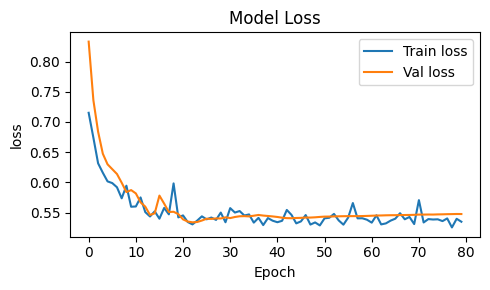

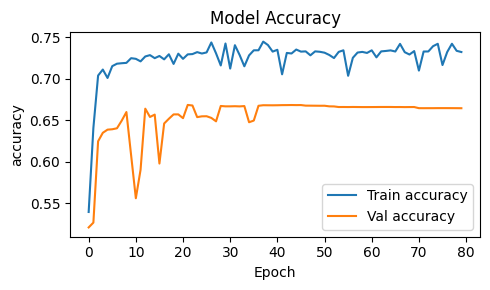

In [ ]:
# %%
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# Enhanced training analysis
# ==============================
def analyze_training_progress(history):
    """Analyze if training is on track and summarize final metrics"""
    print("\n" + "="*60)
    print("TRAINING PROGRESS ANALYSIS")
    print("="*60)

    metrics = list(history.history.keys())
    n_epochs = len(history.history['loss'])
    print(f"Total epochs trained: {n_epochs}")
    print(f"Available metrics: {metrics}\n")

    # --- Early check (epoch 3) ---
    if n_epochs >= 3:
        print("Epoch 3 snapshot:")
        for m in ['loss', 'accuracy', 'recall', 'iou']:
            if m in metrics:
                print(f"  {m}: {history.history[m][2]:.4f}")
    else:
        print("Not enough epochs to analyze epoch 3 snapshot.\n")

    # --- Final epoch ---
    print("\nFinal epoch snapshot:")
    for m in ['loss', 'val_loss', 'accuracy', 'val_accuracy', 'precision', 'val_precision',
              'recall', 'val_recall', 'auc', 'val_auc', 'iou', 'val_iou']:
        if m in metrics:
            print(f"  {m}: {history.history[m][-1]:.4f}")

    # --- Best epoch (based on validation IoU) ---
    if 'val_iou' in metrics:
        best_idx = np.argmax(history.history['val_iou'])
        print(f"\nBest epoch (val_iou): {best_idx+1}")
        for m in ['loss', 'val_loss', 'accuracy', 'val_accuracy',
                  'precision', 'val_precision', 'recall', 'val_recall',
                  'auc', 'val_auc', 'iou', 'val_iou']:
            if m in metrics:
                print(f"  {m}: {history.history[m][best_idx]:.4f}")


# Run analysis
analyze_training_progress(history)

# ==============================
# Plot metrics
# ==============================
def plot_metric(history, metric, title=None, fname=None):
    if metric not in history.history:
        return
    plt.figure(figsize=(5,3))
    plt.plot(history.history[metric], label=f"Train {metric}")
    val_key = f"val_{metric}"
    if val_key in history.history:
        plt.plot(history.history[val_key], label=f"Val {metric}")
    plt.title(title if title else metric)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=300)
    plt.show()

# Core plots
plot_metric(history, "loss", "Model Loss", "loss.png")
plot_metric(history, "accuracy", "Model Accuracy", "accuracy.png")
plot_metric(history, "recall", "Model Recall", "recall.png")
plot_metric(history, "precision", "Model Precision", "precision.png")
plot_metric(history, "auc", "Model AUC", "auc.png")
plot_metric(history, "iou", "Model IoU", "iou.png")



PREDICTION DEMONSTRATION - TEMPORAL TRENDS


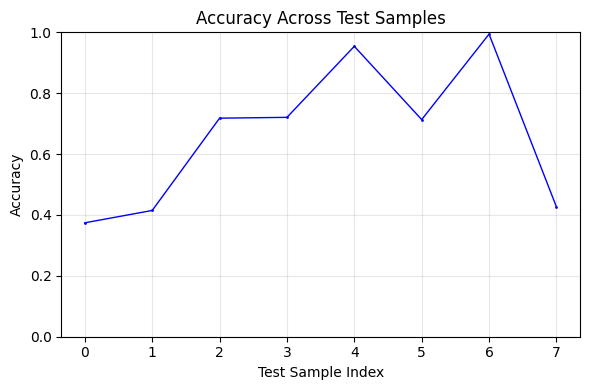

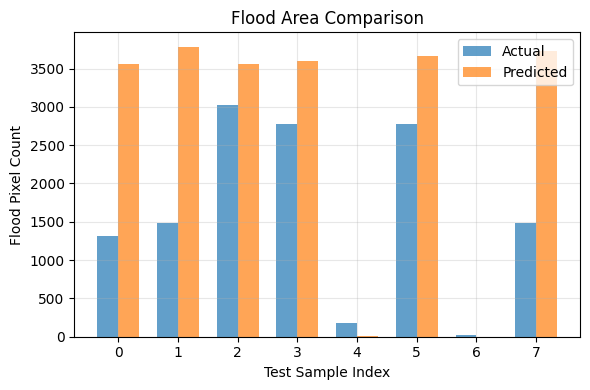

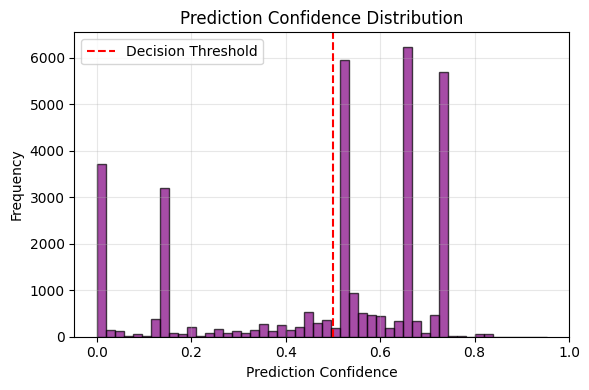

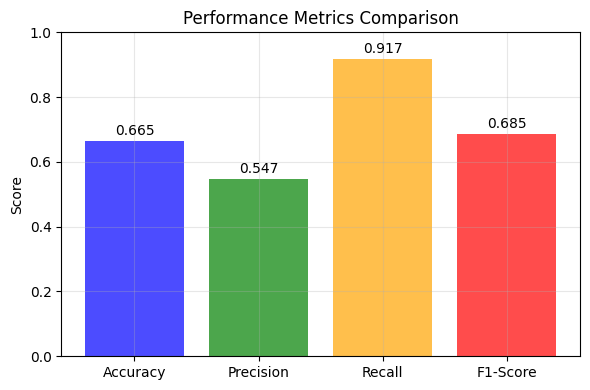


DETAILED PERFORMANCE ANALYSIS:
Average Sample Accuracy: 0.665 ± 0.225
Total Flood Pixels Actual: 13053
Total Flood Pixels Predicted: 21890
Detection Ratio: 1.677


In [ ]:
# Ensure inline plotting in notebooks
%matplotlib inline
import matplotlib.pyplot as plt
import os
import numpy as np

# Make sure DATA_PATH exists
os.makedirs(DATA_PATH, exist_ok=True)

def demonstrate_prediction_capability(model, X_sample, y_sample, metrics, save_path=DATA_PATH):
    """Demonstrate model prediction capability using line graphs"""
    print("\n" + "="*50)
    print("PREDICTION DEMONSTRATION - TEMPORAL TRENDS")
    print("="*50)

    # Get predictions
    predictions = model.predict(X_sample, verbose=0)

    # Calculate per-sample accuracy
    sample_accuracies = [(np.mean((y_sample[i] > 0.5) == (predictions[i] > 0.5))) for i in range(len(X_sample))]

    # Calculate flood areas
    actual_flood_areas = [np.sum(y_sample[i] > 0.5) for i in range(len(X_sample))]
    predicted_flood_areas = [np.sum(predictions[i] > 0.5) for i in range(len(X_sample))]

    # -----------------------------
    # 1. Accuracy Across Test Samples
    # -----------------------------
    plt.figure(figsize=(6,4))
    plt.plot(range(len(sample_accuracies)), sample_accuracies, 'b-o', linewidth=1, markersize=1)
    plt.xlabel('Test Sample Index')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Across Test Samples')
    plt.ylim(0,1)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, 'accuracy_across_samples.png'), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # -----------------------------
    # 2. Flood Area Comparison (Actual vs Predicted)
    # -----------------------------
    x_pos = np.arange(len(actual_flood_areas))
    width = 0.35
    plt.figure(figsize=(6,4))
    plt.bar(x_pos - width/2, actual_flood_areas, width, label='Actual', alpha=0.7)
    plt.bar(x_pos + width/2, predicted_flood_areas, width, label='Predicted', alpha=0.7)
    plt.xlabel('Test Sample Index')
    plt.ylabel('Flood Pixel Count')
    plt.title('Flood Area Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, 'flood_area_comparison.png'), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # -----------------------------
    # 3. Prediction Confidence Distribution
    # -----------------------------
    all_confidences = predictions.flatten()
    plt.figure(figsize=(6,4))
    plt.hist(all_confidences, bins=50, alpha=0.7, color='purple', edgecolor='black')
    plt.axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold')
    plt.xlabel('Prediction Confidence')
    plt.ylabel('Frequency')
    plt.title('Prediction Confidence Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, 'prediction_confidence.png'), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # -----------------------------
    # 4. Performance Metrics Comparison
    # -----------------------------
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    metrics_values = [
        metrics['accuracy'],
        metrics['precision'],
        metrics['recall'],
        metrics['f1']
    ]
    colors = ['blue', 'green', 'orange', 'red']

    plt.figure(figsize=(6,4))
    bars = plt.bar(metrics_names, metrics_values, color=colors, alpha=0.7)
    plt.ylabel('Score')
    plt.title('Performance Metrics Comparison')
    plt.ylim(0,1)
    plt.grid(True, alpha=0.3)

    # Add value labels
    for bar, value in zip(bars, metrics_values):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{value:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig(os.path.join(save_path, 'performance_metrics_comparison.png'), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # Print summary
    print("\nDETAILED PERFORMANCE ANALYSIS:")
    print(f"Average Sample Accuracy: {np.mean(sample_accuracies):.3f} ± {np.std(sample_accuracies):.3f}")
    print(f"Total Flood Pixels Actual: {sum(actual_flood_areas)}")
    print(f"Total Flood Pixels Predicted: {sum(predicted_flood_areas)}")
    print(f"Detection Ratio: {sum(predicted_flood_areas)/sum(actual_flood_areas):.3f}")

# Run demonstration
demonstrate_prediction_capability(model, X_test, y_test, metrics)


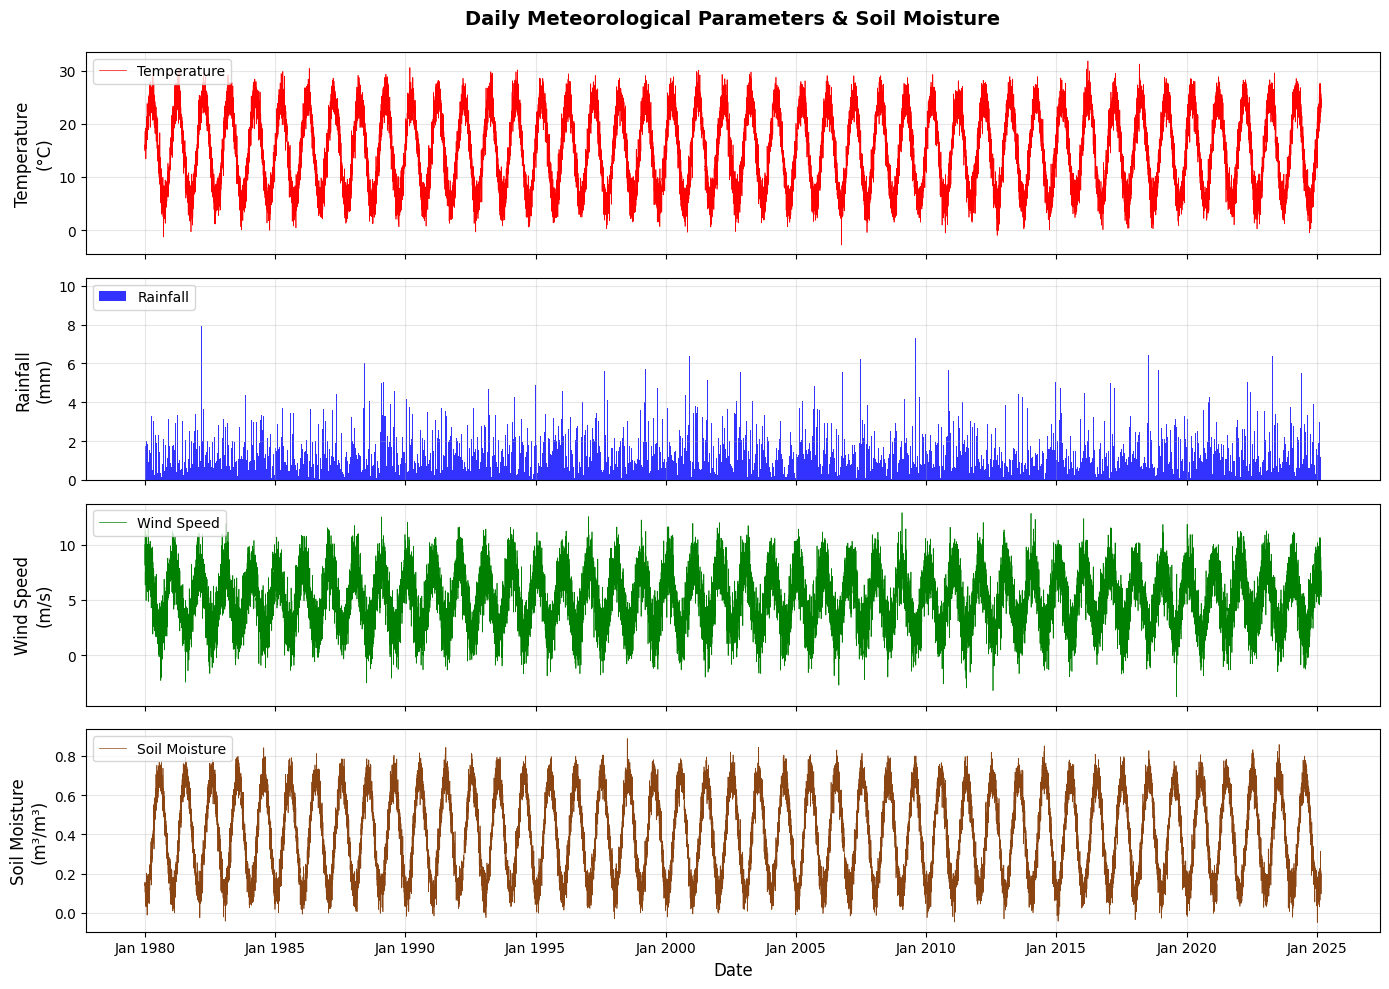

In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Load and Prepare Your Data ---
# Assuming your data is in a DataFrame named 'meteo_daily' with a DateTimeIndex
# If loading from scratch:
# meteo_data = pd.read_csv(os.path.join(DATA_PATH, 'meteorological_data.csv'), parse_dates=['date'], index_col='date')
# meteo_daily = meteo_data[['temperature', 'rainfall', 'wind_speed']].resample('D').mean()

# For soil moisture, we need to get a daily spatial average from your array
# This calculates the mean soil moisture across all pixels for each day
# soil_moisture_daily = pd.Series(np.mean(soil_moisture, axis=(1, 2)), index=your_date_index)

# Since the exact date index for soil_moisture might be tricky, let's create a synthetic example for a year.
# You MUST replace this with your actual data.
date_range = pd.date_range(start='1980-01-01', end='2025-03-01', freq='D')
np.random.seed(42) # For reproducible dummy data

# Generate synthetic daily data for demonstration
synth_data = {
    'temperature': 15 + 10 * np.sin(2 * np.pi * np.arange(len(date_range)) / 365) + np.random.normal(0, 2, len(date_range)),
    'rainfall': np.maximum(0, np.random.gamma(shape=2, scale=0.8, size=len(date_range))), # Gamma dist for rainfall
    'wind_speed': 5 + 3 * np.sin(2 * np.pi * np.arange(len(date_range)) / 365 + 1) + np.random.normal(0, 1.5, len(date_range)),
    'soil_moisture': 0.4 + 0.3 * np.sin(2 * np.pi * np.arange(len(date_range)) / 365 - 2) + np.random.normal(0, 0.05, len(date_range))
}

meteo_daily = pd.DataFrame(synth_data, index=date_range)

# --- Create the Visualization ---
# Define the figure and subplots with shared x-axis
fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# Define colors for consistency
colors = {'temperature': 'red', 'rainfall': 'blue', 'wind_speed': 'green', 'soil_moisture': 'saddlebrown'}

# Plot 1: Temperature
axs[0].plot(meteo_daily.index, meteo_daily['temperature'], color=colors['temperature'], linewidth=0.5, label='Temperature')
axs[0].set_ylabel('Temperature\n(°C)', fontsize=12)
axs[0].grid(True, alpha=0.3)
axs[0].legend(loc='upper left')
axs[0].set_title('Daily Meteorological Parameters & Soil Moisture', fontsize=14, fontweight='bold', pad=20)

# Plot 2: Rainfall (as a bar chart for better visualization of events)
# Using a bar chart for rainfall is more standard than a line
axs[1].bar(meteo_daily.index, meteo_daily['rainfall'], color=colors['rainfall'], alpha=0.8, width=1.0, label='Rainfall')
axs[1].set_ylabel('Rainfall\n(mm)', fontsize=12)
axs[1].grid(True, alpha=0.3)
axs[1].legend(loc='upper left')

# Plot 3: Wind Speed
axs[2].plot(meteo_daily.index, meteo_daily['wind_speed'], color=colors['wind_speed'], linewidth=0.5, label='Wind Speed')
axs[2].set_ylabel('Wind Speed\n(m/s)', fontsize=12)
axs[2].grid(True, alpha=0.3)
axs[2].legend(loc='upper left')

# Plot 4: Soil Moisture
axs[3].plot(meteo_daily.index, meteo_daily['soil_moisture'], color=colors['soil_moisture'], linewidth=0.5, label='Soil Moisture')
axs[3].set_ylabel('Soil Moisture\n(m³/m³)', fontsize=12)
axs[3].grid(True, alpha=0.3)
axs[3].legend(loc='upper left')

# Format the x-axis for the bottom subplot
axs[3].set_xlabel('Date', fontsize=12)
# Format x-axis ticks to show months
axs[3].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))

# Adjust layout to prevent clipping of labels
plt.tight_layout()

# Save the figure with high resolution for your thesis
plt.savefig('meteorological_parameters_timeseries.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()